In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import re
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def get_filtered_filenames(folder_path: str) -> list[str]:
    filenames: list[str] = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and "SnV_" in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

def read_in_data(file_path: str) -> xr.core.dataset.Dataset:
    with open(file_path, 'r') as file:
        # read in metadata
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line: int | None = i
                break
        # read in main data
        data: pd.DataFrame = pd.read_csv(file_path, sep='\t', skiprows=data_start_line, header=None)
        # save as xarray Dataset
        xrData = xr.Dataset(
                data_vars=dict(
                    intensity=xr.Variable('wavelength', data[1] , dict(units=r'au', long_name='Intensity')),             
                ),
                coords=dict(
                    wavelength=xr.Variable('wavelength', data[0]*1e-9, attrs=dict(units=r'nm', long_name='Wavelength')),
                    
                )
            )
    return xrData

def lorentzian(x: float | np.ndarray, x0: float, gamma: float, A: float) -> float | np.ndarray:
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

def get_name(filename: str) -> str | None:
    match: re.Match[str] | None = re.search(r"spectrum_(.*?)\.dat", filename)
    if match:
        return match.group(1)
    return None

def wavelength_to_freq_diff(wavelength1: float, wavelength2: float) -> float:
    # Speed of light in m/s
    c = 3e8
    # Convert wavelengths from nm to meters
    lambda1_m = wavelength1 * 1e-9
    lambda2_m = wavelength2 * 1e-9
    # Calculate frequencies in Hz
    freq1 = c / lambda1_m
    freq2 = c / lambda2_m
    # Frequency difference in Hz
    freq_diff_hz = abs(freq1 - freq2)
    # Convert to GHz
    freq_diff_ghz = freq_diff_hz / 1e9
    
    return freq_diff_ghz

def fit_single_with_peak_finding(x_data: np.ndarray, y_data: np.ndarray) -> tuple[list[float], list[float]]:
    # Find peaks
    peaks, _ = find_peaks(y_data, height=np.max(y_data) * 0.1)  # Detect peaks above 10% of max height
    peak_indice = peaks[np.argsort(y_data[peaks])][-1]  # Get indices of the two tallest peaks  # Ensure order consistency
    # Get guess for peak position
    x01_guess = x_data[peak_indice]
    y01_guess = y_data[peak_indice]
    # Fit
    p0 = [x01_guess, 1, y01_guess]  # Initial guess for second Lorentzian
    popt, pcov = curve_fit(lorentzian, x_data, y_data, p0=p0)
    
    return popt, pcov

def get_filtered_filenames_laser(folder_path: str) -> list[str]:
    filenames: list[str] = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and "laser" in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

def get_wavelength(name: str) -> float:
    match = re.search(r'\d+\.\d+', name)
    return float(match.group())

def linear(x: float | np.ndarray, a: float ,c: float) -> float | np.ndarray:
    return a*x + c

# Fit spectrometer data (find laser peaks)

In [ ]:
folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/Data/spectrometer_calib'
filepaths = get_filtered_filenames_laser(folder_path)

data_dict = {}
not_fitted = []
for filepath in filepaths:
    xrData = read_in_data(f"{folder_path}/{filepath}")
    popt, pcov = fit_single_with_peak_finding(np.array(xrData.wavelength), np.array(xrData.intensity))
    if popt is not None:
        xrData.attrs["name"] = get_name(filename=filepath)
        xrData.attrs["popt"] = popt
        data_dict[get_name(filepath)] = xrData
    else:
        not_fitted.append(get_name(filepath))

print(f"Not fitted: {not_fitted}")

wl_spectrometer = []
wl_wavemeter = []
for xrData in data_dict.values():
   print(f"Wavemeter pos: {get_wavelength(xrData.attrs['name'])}, Spectrometer pos: {xrData.attrs['popt'][0]:.5f} nm")
   wl_spectrometer.append(xrData.attrs['popt'][0])
   wl_wavemeter.append(get_wavelength(xrData.attrs['name']))

Not fitted: []
Wavemeter pos: 622.42138, Spectrometer pos: 624.32049 nm
Wavemeter pos: 621.14217, Spectrometer pos: 622.62450 nm
Wavemeter pos: 623.71625, Spectrometer pos: 626.23459 nm
Wavemeter pos: 625.01542, Spectrometer pos: 627.49416 nm
Wavemeter pos: 617.57997, Spectrometer pos: 617.75742 nm
Wavemeter pos: 615.72882, Spectrometer pos: 615.30353 nm
Wavemeter pos: 619.22283, Spectrometer pos: 619.99999 nm


# Fit "spectrometer wavelength" vs "wavemeter wavlength"

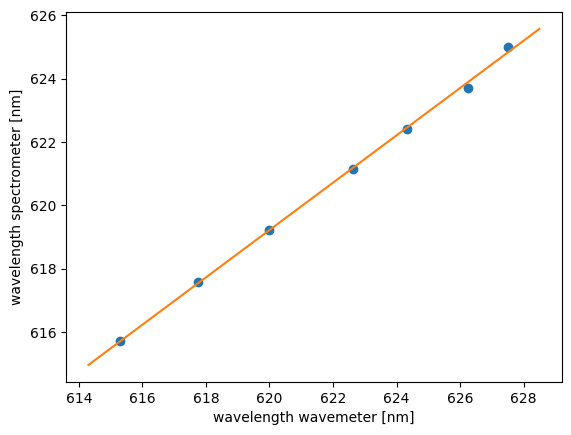

In [3]:
# Fit linear relation between measured wavelength of wavemeter and spectrometer
popt, pcov = curve_fit(linear, wl_spectrometer, wl_wavemeter)

# Save wavelength data for measured points from wavemeter and spectrometer in xr Dataset
xrCalib = xr.Dataset(
    data_vars=dict(
        wl_wavemeter=xr.Variable('wl_spectrometer', wl_wavemeter , dict(units=r'nm', long_name='wavelength spectrometer')),             
    ),
    coords=dict(
        wl_spectrometer=xr.Variable('wl_spectrometer', wl_spectrometer, attrs=dict(units=r'nm', long_name='wavelength wavemeter')),
        
    )
)
# Add fit results to xr Dataset
xrCalib.attrs['popt'] = popt
xrCalib.attrs['pcov'] = pcov

# Plot Fit
xrCalib.wl_wavemeter.plot(marker='o', linestyle='none')
x_plot = np.linspace(xrCalib.wl_spectrometer.min()-1, xrCalib.wl_spectrometer.max()+1, 100) 
plt.plot(x_plot, linear(x_plot, *xrCalib.attrs['popt']))
plt.show()

# Save calibration data

In [ ]:
calibration_file_name = "calibration_20_12_2024"
xrCalib.to_netcdf(f"{calibration_file_name}.h5", engine="h5netcdf") # pip install h5netcdf may be nesessary